# Overview

**Single-Agent Fusion (Blind) Pipeline**

This notebook implements the a single-agent fusion pipeline for the Fake News Detection project.  
In this setup, the LLM agent **cannot see the image directly**. Instead, it relies on:

- the human-provided **headline**,  
- an AI-generated **image description**, and  
- a set of **forensic tools**

to decide whether a news item is real or fake.

The goal of this notebook is to:

- Evaluate how well a structured, tool-using LLM agent can detect fake news without direct visual access  
- Compare the agent's decisions to unimodal baselines:
  - CLIP zero-shot image classifier (vision-only)
  - RoBERTa fake-news classifier on headlines and captions (text-only)
- Study the effect of fusion by comparing:
  - the agent's **initial impression** (headline-based only)
  - the agent's **final decision** after consulting tools  
- Analyze when tool fusion helps, when it hurts, and how often the agent changes its mind

This pipeline exposes two levels of prediction:

1. **Tool-Level Predictions (Baselines)**  
   - **Vision Tool (CLIP):**  
     Zero-shot `openai/clip-vit-base-patch32` predicts Fake/Real from the image and extracts top-k visual concepts.  
   - **Text Tool (RoBERTa + VADER):**  
     A Fakeddit-trained RoBERTa classifier (`yaoyinnan/roberta-fakeddit`) labels the headline as Fake/Real with a confidence score, and VADER computes a sentiment score (e.g., for sensationalism).  
   - **Consistency Tool (MPNet + CLIP):**  
     `all-mpnet-base-v2` measures semantic similarity between headline and BLIP-2 caption (generated by `Salesforce/blip2-opt-2.7b`), and CLIP computes cross-modal similarity between the image and both texts.

2. **Agent-Level Decisions (LLM Reasoning)**  
   - `gpt-4.1-mini` is used as a LangChain legacy agent (`AgentExecutor` + `create_tool_calling_agent`).  
   - It follows a **phase-based protocol**:
     1. Form an initial impression (Real/Fake) from the headline only  
     2. Check the reliability of the AI image description  
     3. Call the vision, text, and consistency tools as "forensic sensors"  
     4. Compare intuition vs tool evidence and output a final decision  
   - The agent returns:
     - `Initial_Impression` and `Final_Decision` (Fake / Real)  
     - `Did_Decision_Change` (Yes / No) and `Decision_Confidence` (High/Medium/Low)  
     - A detailed `Explanation` and a user-facing `Nudge`  

---

**What This Notebook Covers**

- Load:  
\- The preprocessed Fakeddit subset and images (N=225)  
\- BLIP-2 captions (precomputed in the metadata)  
\- Visual concepts embeddings (precomputed)  
- Define the three LangChain tools (vision, text, consistency)
- Compute Top-K visual concepts using ImageNet + Places365 concept embeddings
- Perform CLIP zero-shot real/fake classification
- Classify both headline and BLIP captions using RoBERTa
- Perform sentiment analysis using VADER
- Compute semantic similarity between headline and caption using MPNet SentenceTransformer
- Compute cross-modal similarity between image and texts (headline+caption) using CLIP
- Build the blind agent (GPT) with a structured system prompt and a phase-based workflow
- Fuse all signals using GPT-4.1-mini for reasoning
- Evaluate performances (CLIP, RoBERTa, GPT)
- Discuss how tool fusion and lack of direct visual access affect the agent's performance

This notebook serves as an intermediate LangChain-based fusion baseline before building the full multimodal agentic system.

# Setup (LangChain Legacy Agents Compatibility Fix)

This notebook uses **LangChain legacy agents** (e.g. `AgentExecutor`, `create_tool_calling_agent`), which are **not compatible with the latest LangChain releases** shipped in Colab by default.

To avoid version conflicts:

1. Uninstall any preinstalled `numpy`, `pandas`, and `langchain*` packages.
2. Install a set of versions that are known to work with the legacy agents used in this notebook.

> **Important:** After running the two cells below,   
> you **must restart the runtime** (`Runtime → Restart session`) before continuing.  
> If you do not restart, Python may still use the old in-memory versions, and imports / agents can fail in confusing ways.

In [1]:
# Uninstall the conflicting packages to start fresh
!pip uninstall -y numpy pandas langchain langchain-core langchain-community langchain-openai


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: langchain 1.1.2
Uninstalling langchain-1.1.2:
  Successfully uninstalled langchain-1.1.2
Found existing installation: langchain-core 1.1.1
Uninstalling langchain-core-1.1.1:
  Successfully uninstalled langchain-core-1.1.1


In [2]:
# Install the exact compatible stack for Colab + Legacy Agents
!pip install -q "numpy==1.26.4" \
                "pandas==2.2.2" \
                "scikit-learn" \
                "langchain==0.3.0" \
                "langchain-core==0.3.0" \
                "langchain-community==0.3.0" \
                "langchain-openai==0.2.0" \
                "vaderSentiment"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.1/405.1 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curren

**IMPORTANT REMINDER:** Now restart the runtime (Runtime → Restart session) before running the next cells.

# Setup (Dependencies & Imports)

Install dependencies, clone the repo, and import required libraries and modules.

In [1]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 159 (delta 79), reused 29 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 18.29 MiB | 9.46 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import json

from tqdm import tqdm
from PIL import Image
from numpy.linalg import norm

# ML/DL libraries
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report

# LangChain
from langchain.tools import tool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client

In [3]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [4]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [5]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_subset_blip2captions.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
image_df.head()


Loaded 225 clean samples.
Shape subset: (225, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,https://preview.redd.it/r05zlwu9ceo31.jpg?widt...,the back end of a black audi parked at a gas s...
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,https://external-preview.redd.it/WYnfGnWhlS17K...,a man in white clothes is surrounded by police...
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,https://preview.redd.it/2bvyzw2ou2tz.jpg?width...,a woman sitting in a chair with the words flam...
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,https://external-preview.redd.it/QupwrX2NA0Tzo...,a brown box with a black face on it
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,https://external-preview.redd.it/6ZR075IHnrgw1...,lays chips are in a display case


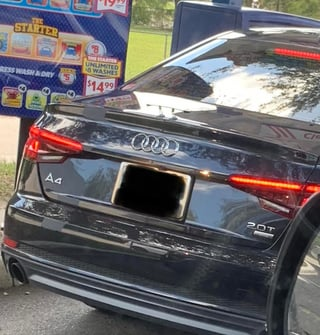

In [6]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [7]:
# Sample N images for testing (around 10-50)
N = 50
sample_df = image_df.sample(N, random_state=42).reset_index(drop=True)
sample_df.head()

,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this extremely long fry from arbys,1,https://preview.redd.it/1cbilca4ufi31.jpg?widt...,a person holding a long orange string
1,/content/FakeNews/assets/content/fakeddit_imag...,boise parks and rec to employ the homeless,1,https://external-preview.redd.it/pM-zpj7zb34SW...,a group of people sitting at a table with papers
2,/content/FakeNews/assets/content/fakeddit_imag...,this japanese restaurant has a paper holder fo...,1,https://external-preview.redd.it/enlHPTM-kcVCB...,a wooden chopstick on a table with a cup of tea
3,/content/FakeNews/assets/content/fakeddit_imag...,avengers infinity war,0,https://preview.redd.it/hzvhmtqaa4v01.png?widt...,a colorful windows logo with squares
4,/content/FakeNews/assets/content/fakeddit_imag...,this red sunset,1,https://preview.redd.it/1b6hu7tk4dt31.jpg?widt...,the sun sets behind a beach and trees


In [8]:
# Load visual concepts list
assets_dir = "/content/FakeNews/assets"
with open(os.path.join(assets_dir, "concepts_list.json"), "r") as f:
    concepts_list = json.load(f)

# Load visual concept embeddings
concept_embs = np.load(os.path.join(assets_dir, "concept_embeddings.npy"))
print(f"Loaded {len(concepts_list)} concepts and embedding matrix {concept_embs.shape}")

Loaded 1365 concepts and embedding matrix (1365, 512)


# Model & Tools

Lood all the models and define the LangChain tools.

In [9]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# RoBERTa
roberta_name = "yaoyinnan/roberta-fakeddit"
roberta_tok = AutoTokenizer.from_pretrained(roberta_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_model.to(device)
roberta_model.eval()
print("\n-----------------------------------------------------")
print("RoBERTa loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")

# Sentiment Heuristic (VADER)
vader_analyzer = SentimentIntensityAnalyzer()

print("\n-----------------------------------------------------")
print("All models loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------

-----------------------------------------------------
All models loaded successfully.
-----------------------------------------------------


## Vision Tool

Gather all visual evidence through CLIP.

In [11]:
# Define labels for CLIP prompts
label_prompts = [
    "a staged or manipulated fake news photo",
    "a real photo from a legitimate news report"
]

In [12]:
@tool
def vision_tool(image_path: str) -> dict:
    """
    Analyzes an image file.
    Returns: top visual concepts (CLIP), and Fake/Real classification (CLIP Zero-Shot).
    """
    image = Image.open(image_path).convert("RGB")

    # CLIP features (for concepts and zero-shot)
    inputs = clip_processor(images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    img_vec = img_emb.squeeze().cpu().numpy()

    # 1. Top-K Concepts
    k=5
    img_vec_norm = img_vec / norm(img_vec)
    concept_mags = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims = concept_embs_norm @ img_vec_norm
    topk_idx = sims.argsort()[::-1][:k]
    topk = [f"{concepts_list[i]} ({sims[i]:.2f})" for i in topk_idx]

    # 2. CLIP Zero-Shot
    text_inputs = clip_processor(text=label_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embs = clip_model.get_text_features(**text_inputs)

    # Calculate similarity for ZS (manual dot product)
    text_embs_norm = text_embs / text_embs.norm(dim=1, keepdim=True)
    img_emb_norm = img_emb / img_emb.norm(dim=1, keepdim=True)
    logits = (img_emb_norm @ text_embs_norm.T).squeeze()
    probs = logits.softmax(dim=0).cpu().numpy()

    zs_pred_idx = np.argmax(probs)
    zs_label = "Real" if zs_pred_idx == 1 else "Fake"
    zs_conf = float(probs[zs_pred_idx])

    return {

            "visual_concepts": topk,
            "clip_zs_label": zs_label,
            "clip_zs_confidence": zs_conf
    }


## Text Tool

Gather all textual evidence through RoBERTa and VADER.

In [13]:
@tool
def text_tool(user_text: str, AI_caption: str) -> dict:
    """
    Analyzes BOTH the User Headline and the AI Caption in one batch.
    Returns: RoBERTa classification and VADER scores for both texts.
    """

    results = {}

    # Process both texts in a loop to avoid code duplication
    inputs = {"user_text": user_text, "AI_caption": AI_caption}

    for key, text_content in inputs.items():
        # 1. RoBERTa Classification
        tokens = roberta_tok(text_content, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            out = roberta_model(**tokens)
            probs = F.softmax(out.logits, dim=1).squeeze()

        pred_idx = torch.argmax(probs).item()
        label = "Fake" if pred_idx == 0 else "Real"
        conf = float(probs[pred_idx])

        # 2. VADER Sentiment
        sentiment = vader_analyzer.polarity_scores(text_content)["compound"]

        # Store results with specific keys
        results[f"{key}_roberta_label"] = label
        results[f"{key}_roberta_conf"] = conf
        results[f"{key}_vader_sentiment"] = sentiment

    return results


## Consistency Tool

Gather all multimodal alignment evidence through MPNet and CLIP.

In [14]:
@tool
def consistency_tool(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes three-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    3. Cross-modal: Image vs Caption (BLIP-2 Fidelity Check)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()  # in [-1, 1]

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text & Image-to-Caption)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text, AI_caption], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    sims = (img_feats @ txt_feats.T).squeeze()  # shape (2,), values in [-1, 1]

    # image vs headline = index 0, image vs caption = index 1
    img_text_sim = float(sims[0].item())
    img_cap_sim  = float(sims[1].item())

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim,
        "image_to_caption_similarity": img_cap_sim
    }


# Agentic Reasoning (GPT Fusion Layer)

Provide reasoning and final decision through GPT.

In [74]:
# Agent setup
tools = [vision_tool, text_tool, consistency_tool]

# Define the System Prompt
system_prompt = """
You are a Misinformation Detection Expert Analyst.
Your goal is to distinguish between **Malicious Fake News** and **Benign Content**.
You do not have direct access to the image of news but you can use your tools to analyze it.
Therefore, you must rely on:
- the HEADLINE,
- the AI_IMAGE_DESCRIPTION,
- and the outputs of your forensic tools.

CORE PHILOSOPHY:
Form an initial judgment from the headline alone, then use tools as your "forensic senses" for the hidden image and deeper signals.

YOUR TOOLKIT:
1. Vision Tool:
   - Detects visual concepts in the image.
   - Flags the image as potentially Fake or Real using a vision classifier.
2. Text Tool:
   - Analyzes BOTH the user-provided headline and the AI-generated image description.
   - Flags each as potentially Fake or Real using a fake-news classifier.
   - Measures sentiment (e.g., sensationalism) using sentiment analysis.
3. Consistency Tool:
   - Measures how well the image, AI description, and headline align using semantic and cross-modal similarity:
     - text_to_caption_similarity: cosine similarity between headline and AI caption (range [-1, 1]).
     - image_to_text_similarity: cosine similarity between image and headline (range [-1, 1]).
     - image_to_caption_similarity: cosine similarity between image and AI caption (range [-1, 1]).

IMPORTANT TOOL RULES:
- Before giving your final answer, you MUST call:
  - vision_tool
  - text_tool
  - consistency_tool
- Use the actual tool outputs as evidence. Do NOT invent or fabricate tool results.
- You may change your initial intuition if the tools provide strong contradictory evidence.

DATA GATHERING PROTOCOL:

PHASE 1: DIRECT OBSERVATION (System 1 Intuition)
- For your initial impression, you MUST rely ONLY on the provided HEADLINE.
- IGNORE the AI image description in this phase.
- Then choose your initial impression: "Real" or "Fake", and explain briefly WHY based on what you READ in the headline.

PHASE 2: IMAGE DESCRIPTION RELIABILITY (Reliability Check)
- You are provided with an AI-generated Image Description.
- Compare this description with the HEADLINE.
- Is the description aligned with the headline?
  - If YES: You may treat the description as a potentially useful complement to the headline.
  - If NO: The description might be hallucinated or vague, treat it with caution in later reasoning.

PHASE 3: FORENSIC CONSULTATION (System 2 Forensics)
- Call vision_tool to:
  - Check which visual concepts are detected.
  - See whether the image is predicted as Fake or Real, and with what confidence.
- Call text_tool to:
  - Check whether the headline and AI caption are predicted as Fake or Real, and with what confidence.
  - Inspect their sentiment scores (e.g., very extreme or sensational tone).
- Call consistency_tool to:
  - Measure alignment between:
    - Headline and AI caption (semantic similarity).
    - Image and Headline (cross-modal similarity).
    - Image and AI caption (cross-modal similarity).
  - High values near 1.0 indicate strong alignment, values near 0 indicate weak or generic alignment, and values below 0 indicate contradiction.

PHASE 4: SYNTHESIS (The Verdict)
- Compare Phase 1 (Intuition) with Phase 3 (Forensics).
- Check whether the tools found something you missed.
- Reflect explicitly: did the tools change your mind?
- Then choose a final classification: "Real" or "Fake".

CONFIDENCE FIELD:
When setting "Decision_Confidence":
- Use "High" if most tools strongly agree with each other and with your final decision.
- Use "Medium" if the evidence is mixed but clearly leans toward your final decision.
- Use "Low" if the evidence is weak or conflicting and you had to choose despite uncertainty.

OUTPUT FORMAT:
Return a single JSON object (no markdown, no extra commentary), with this exact structure:

{{
  "Initial_Impression": "Real" or "Fake",
  "Initial_Reasoning": "Brief summary of your initial impression.",
  "Final_Decision": "Real" or "Fake",
  "Did_Decision_Change": "Yes" or "No",
  "Decision_Confidence": "High" or "Medium" or "Low",
  "Explanation": "Detailed narrative. Start with your intuition, mention whether the AI description was reliable, and explain how the tool evidence confirmed or refuted your initial thought.",
  "Nudge": "One actionable piece of advice for the user about how to think more critically about similar content in the future."
}}

"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0) # or gpt-4o-mini
agent = create_tool_calling_agent(llm, tools, prompt)


In [75]:
# Example run before running full loop (with verbose=True)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

row = sample_df.iloc[4]
current_image_path = row['image_path']
current_headline = row['clean_title']
current_AIcaption = row['blip2_caption']

user_input = [
        {
            "type": "text",
            "text": f"""
Please analyze this news item using your tools.

HEADLINE: "{current_headline}"
AI_IMAGE_DESCRIPTION: "{current_AIcaption}"
LOCAL_IMAGE_PATH: "{current_image_path}"

Use this LOCAL_IMAGE_PATH string exactly when calling:
- vision_tool(image_path=LOCAL_IMAGE_PATH)
- consistency_tool(user_text=HEADLINE, AI_caption=AI_IMAGE_DESCRIPTION, image_path=LOCAL_IMAGE_PATH)
            """.strip()
        }
    ]

response = agent_executor.invoke({"input": user_input})
# print(response["output"])



Invoking: `vision_tool` with `{'image_path': '/content/FakeNews/assets/content/fakeddit_images/196.jpg'}`


{'visual_concepts': ['beach house (0.25)', 'promontory (0.24)', 'islet (0.24)', 'promenade (0.24)', 'boardwalk (0.24)'], 'clip_zs_label': 'Fake', 'clip_zs_confidence': 0.5003951191902161}
Invoking: `text_tool` with `{'user_text': 'this red sunset', 'AI_caption': 'the sun sets behind a beach and trees'}`


{'user_text_roberta_label': 'Real', 'user_text_roberta_conf': 0.9060823917388916, 'user_text_vader_sentiment': 0.0, 'AI_caption_roberta_label': 'Fake', 'AI_caption_roberta_conf': 0.8076130151748657, 'AI_caption_vader_sentiment': 0.0}
Invoking: `consistency_tool` with `{'user_text': 'this red sunset', 'AI_caption': 'the sun sets behind a beach and trees', 'image_path': '/content/FakeNews/assets/content/fakeddit_images/196.jpg'}`


{'text_to_caption_similarity': 0.4991365969181061, 'image_to_text_similarity': 0.25853869318962097, 'image_to_caption_similarity': 0.2865173816680908}

In [102]:
# Make Verbose=False to keep output clean
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

# Run pipeline
results = []

# Iterate through the DataFrame
for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    current_image_path = row['image_path']
    current_headline = row['clean_title']
    current_AIcaption = row['blip2_caption']
    true_label = row['label']

    # Create Structured Input (Text)
    user_input = [
        {
            "type": "text",
            "text": f"""
Please analyze this news item using your tools.

HEADLINE: "{current_headline}"
AI_IMAGE_DESCRIPTION: "{current_AIcaption}"
LOCAL_IMAGE_PATH: "{current_image_path}"

Use this LOCAL_IMAGE_PATH string exactly when calling:
- vision_tool(image_path=LOCAL_IMAGE_PATH)
- consistency_tool(user_text=HEADLINE, AI_caption=AI_IMAGE_DESCRIPTION, image_path=LOCAL_IMAGE_PATH)
            """.strip()
        }
    ]

    try:
        # Run the Agent
        response = agent_executor.invoke({"input": user_input})

        # Extract output
        output_text = response['output']

        # Clean markdown code blocks if present
        clean_json = output_text.replace("```json", "").replace("```", "").strip()

        # Parse JSON output
        decision_data = json.loads(clean_json)

        # Baseline predictions (CLIP & RoBERTa)
        vision_res = vision_tool.invoke({"image_path": current_image_path})
        text_res   = text_tool.invoke({"user_text": current_headline, "AI_caption": current_AIcaption})

        # Store all fields
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "true_label": true_label,
            "blip2_caption": current_AIcaption,

            # Tool predictions
            "clip_label": vision_res.get("clip_zs_label"),
            "roberta_text_label": text_res.get("user_text_roberta_label"),
            "roberta_cap_label": text_res.get("AI_caption_roberta_label"),

            # Decision fields
            "initial_impression": decision_data.get("Initial_Impression"),
            "initial_reasoning": decision_data.get("Initial_Reasoning"),
            "final_decision": decision_data.get("Final_Decision"),
            "changed_mind": decision_data.get("Did_Decision_Change"),
            "confidence": decision_data.get("Decision_Confidence"),

            # Explanation
            "explanation": decision_data.get("Explanation"),
            "nudge": decision_data.get("Nudge"),

            # Debugging
            "raw_output": output_text
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        results.append({
            "image_path": current_image_path,
            "headline": current_headline,
            "error": str(e)
        })

# Save results
results_df = pd.DataFrame(results)
print("\nProcessing Complete.")
results_df.head()


 72%|███████▏  | 162/225 [21:49<06:35,  6.28s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 92%|█████████▏| 207/225 [27:09<02:15,  7.51s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3


Processing Complete.


,image_path,headline,true_label,blip2_caption,clip_label,roberta_text_label,roberta_cap_label,initial_impression,initial_reasoning,final_decision,changed_mind,confidence,explanation,nudge,raw_output
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,the back end of a black audi parked at a gas s...,Real,Real,Real,Real,The headline 'this tiny spoiler on this car' s...,Real,No,High,My initial impression was that the headline is...,"When evaluating similar content, pay attention...","{\n ""Initial_Impression"": ""Real"",\n ""Initial..."
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,a man in white clothes is surrounded by police...,Real,Fake,Fake,Fake,The headline is incoherent and grammatically i...,Fake,No,High,My initial impression based on the headline al...,When encountering confusing or poorly written ...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,a woman sitting in a chair with the words flam...,Real,Fake,Real,Fake,The headline 'flamingo bros where are my shoes...,Fake,No,High,"Initially, the headline seemed suspicious due ...",When encountering vague or nonsensical headlin...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,a brown box with a black face on it,Real,Real,Fake,Fake,The headline 'people really did buy poop on bl...,Fake,No,High,My initial intuition was that the headline was...,Be cautious of sensational headlines that seem...,"{\n ""Initial_Impression"": ""Fake"",\n ""Initial..."
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,lays chips are in a display case,Real,Real,Fake,Real,The headline about chips and salsa being stole...,Real,No,Medium,"Initially, the headline seemed like a believab...","When evaluating news about specific incidents,...","{\n ""Initial_Impression"": ""Real"",\n ""Initial..."


In [138]:
# Review a sample
results_df.iloc[13]

,13
image_path,/content/FakeNews/assets/content/fakeddit_imag...
headline,gunowner who shot at lost teen had previously ...
true_label,1
blip2_caption,two men are shown in this mug shot
clip_label,Real
roberta_text_label,Real
roberta_cap_label,Fake
initial_impression,Real
initial_reasoning,The headline reports a specific incident invol...
final_decision,Real


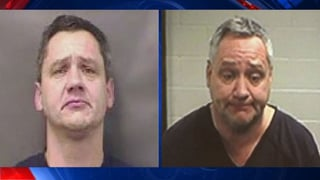

In [113]:
# Image
Image.open(results_df.image_path[13])

In [ ]:
# Headline
results_df.headline[13]

'gunowner who shot at lost teen had previously been charged in roadrage shooting incident rochester hills mi'

In [ ]:
# AI description
image_df.blip2_caption[13]

'two men are shown in this mug shot'

In [ ]:
# GPT's reasoning
results_df.explanation[13]

"Initially, the headline seemed credible as it described a concrete event with specific details (location, prior charge). The AI image description 'two men are shown in this mug shot' aligns reasonably with the headline about a gunowner and a prior incident, suggesting the image is relevant. The vision tool detected some unrelated visual concepts but classified the image as Real with moderate confidence. The text tool strongly classified the headline as Real with high confidence, though it flagged the AI caption as Fake, likely due to its generic nature and lack of detail. Sentiment analysis showed the headline had a somewhat negative tone, consistent with the serious subject matter, while the caption was neutral. The consistency tool showed low to moderate alignment scores between headline, caption, and image, indicating some semantic and visual connection but not very strong. Overall, the forensic tools support the headline's credibility, and the image is not flagged as manipulated o

In [ ]:
# GPT's advice
results_df.nudge[13]

'When evaluating news about crimes or incidents, check for specific details like names, locations, and prior history, and see if the accompanying images and descriptions clearly support those details rather than being vague or generic.'

In [135]:
# GPT's first impression dist (without tools)
display(results_df.initial_impression.value_counts())

# GPT's final decision dist (after using tools)
display(results_df.final_decision.value_counts())

# How often GPT changed opinion
display(results_df.changed_mind.value_counts())

# How confident GPT was about the final decisions after fusion
display(results_df.confidence.value_counts())

,count
initial_impression,
Fake,133
Real,92


,count
final_decision,
Fake,159
Real,66


,count
changed_mind,
No,179
Yes,46


,count
confidence,
High,134
Medium,91


# Quick Evaluation (Metrics & Visualizations)

Compute accuracy, confusion matrix, and classification report for GPT's final decision.

In [130]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None # for errors / missing / unexpected values

results_df["true_label"] = results_df["true_label"].astype(int)
results_df["llm_label"] = results_df["final_decision"].apply(label_to_int)

# Clean unclear or invalid LLM decisions (if any)
llm_clean = results_df.dropna(subset=["llm_label"])


In [131]:
# Accuracies
llm_acc  = np.mean(llm_clean["llm_label"] == llm_clean["true_label"])
llm_cov  = len(llm_clean) / len(results_df)

print("LLM accuracy:", round(llm_acc, 3))
print("LLM coverage:", round(llm_cov, 3))


LLM accuracy: 0.609
LLM coverage: 1.0


In [139]:
# Confusion matrices

# LLM classifier CM
llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])

print("\nGPT-4.1-mini Confusion Matrix:\n", llm_cm)



GPT-4.1-mini Confusion Matrix:
 [[73  2]
 [86 64]]


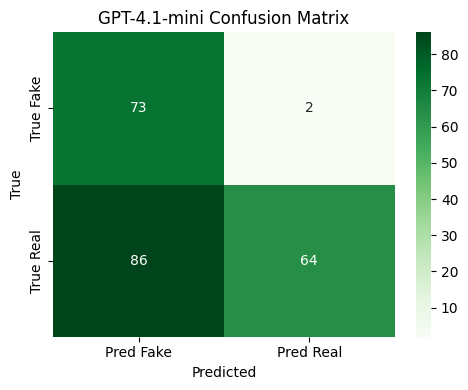

In [133]:
# Heatmaps
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=ax)
ax.set_title("GPT-4.1-mini Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [136]:
# Classification reports
print("\n-----------------------------------------------------")
print("GPT-4.1-mini Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    llm_clean["true_label"],
    llm_clean["llm_label"],
    target_names=["Fake", "Real"]
))



-----------------------------------------------------
GPT-4.1-mini Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.46      0.97      0.62        75
        Real       0.97      0.43      0.59       150

    accuracy                           0.61       225
   macro avg       0.71      0.70      0.61       225
weighted avg       0.80      0.61      0.60       225



# Detailed Evaluation (Performance Comparisons)

Compare classification performances: CLIP, RoBERTa, GPT pre-fuse, GPT post-fuse.

In [103]:
# Make a copy so the original labels are preserved
res_df = results_df.copy()

# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # for errors / missing / unexpected values

# Create new int columns, so keep the str columns unchanged
res_df["true_label_int"]       = res_df["true_label"].astype(int)
res_df["clip_label_int"]       = res_df["clip_label"].apply(label_to_int)
res_df["roberta_text_int"]     = res_df["roberta_text_label"].apply(label_to_int)
res_df["roberta_cap_int"]      = res_df["roberta_cap_label"].apply(label_to_int)
res_df["gpt_pre_int"]          = res_df["initial_impression"].apply(label_to_int)
res_df["gpt_post_int"]         = res_df["final_decision"].apply(label_to_int)


In [104]:
# Accuracies
clip_acc   = np.mean(res_df["clip_label_int"]     == res_df["true_label_int"])
robertaT_acc = np.mean(res_df["roberta_text_int"] == res_df["true_label_int"])
robertaC_acc = np.mean(res_df["roberta_cap_int"]  == res_df["true_label_int"])
gpt1_acc   = np.mean(res_df["gpt_pre_int"]        == res_df["true_label_int"])
gpt2_acc   = np.mean(res_df["gpt_post_int"]       == res_df["true_label_int"])

print("CLIP (Vision) accuracy:", round(clip_acc, 3))
print("RoBERTa (Text-Headline) accuracy:", round(robertaT_acc, 3))
print("RoBERTa (Text-Caption) accuracy:", round(robertaC_acc, 3))
print("GPT (Pre-Fuse) accuracy:", round(gpt1_acc, 3))
print("GPT (Post-Fuse) accuracy:", round(gpt2_acc, 3))


CLIP (Vision) accuracy: 0.573
RoBERTa (Text-Headline) accuracy: 0.924
RoBERTa (Text-Caption) accuracy: 0.493
GPT (Pre-Fuse) accuracy: 0.698
GPT (Post-Fuse) accuracy: 0.609


In [105]:
# Confusion matrices

# CLIP CM
clip_cm = confusion_matrix(res_df["true_label_int"], res_df["clip_label_int"])

# RoBERTa CM
robertaT_cm = confusion_matrix(res_df["true_label_int"], res_df["roberta_text_int"])
robertaC_cm = confusion_matrix(res_df["true_label_int"], res_df["roberta_cap_int"])

# GPT pre-fuse CM
gpt1_cm = confusion_matrix(res_df["true_label_int"], res_df["gpt_pre_int"])

# GPT post-fuse CM
gpt2_cm = confusion_matrix(res_df["true_label_int"], res_df["gpt_post_int"])

print("\nCLIP (Vision) Confusion Matrix:\n", clip_cm)
print("\nRoBERTa (Text-Headline) Confusion Matrix:\n", robertaT_cm)
print("\nRoBERTa (Text-Caption) Confusion Matrix:\n", robertaC_cm)
print("\nGPT (Pre-Fuse) Confusion Matrix:\n", gpt1_cm)
print("\nGPT (Post-Fuse) Confusion Matrix:\n", gpt2_cm)



CLIP (Vision) Confusion Matrix:
 [[ 14  61]
 [ 35 115]]

RoBERTa (Text-Headline) Confusion Matrix:
 [[ 72   3]
 [ 14 136]]

RoBERTa (Text-Caption) Confusion Matrix:
 [[51 24]
 [90 60]]

GPT (Pre-Fuse) Confusion Matrix:
 [[70  5]
 [63 87]]

GPT (Post-Fuse) Confusion Matrix:
 [[73  2]
 [86 64]]


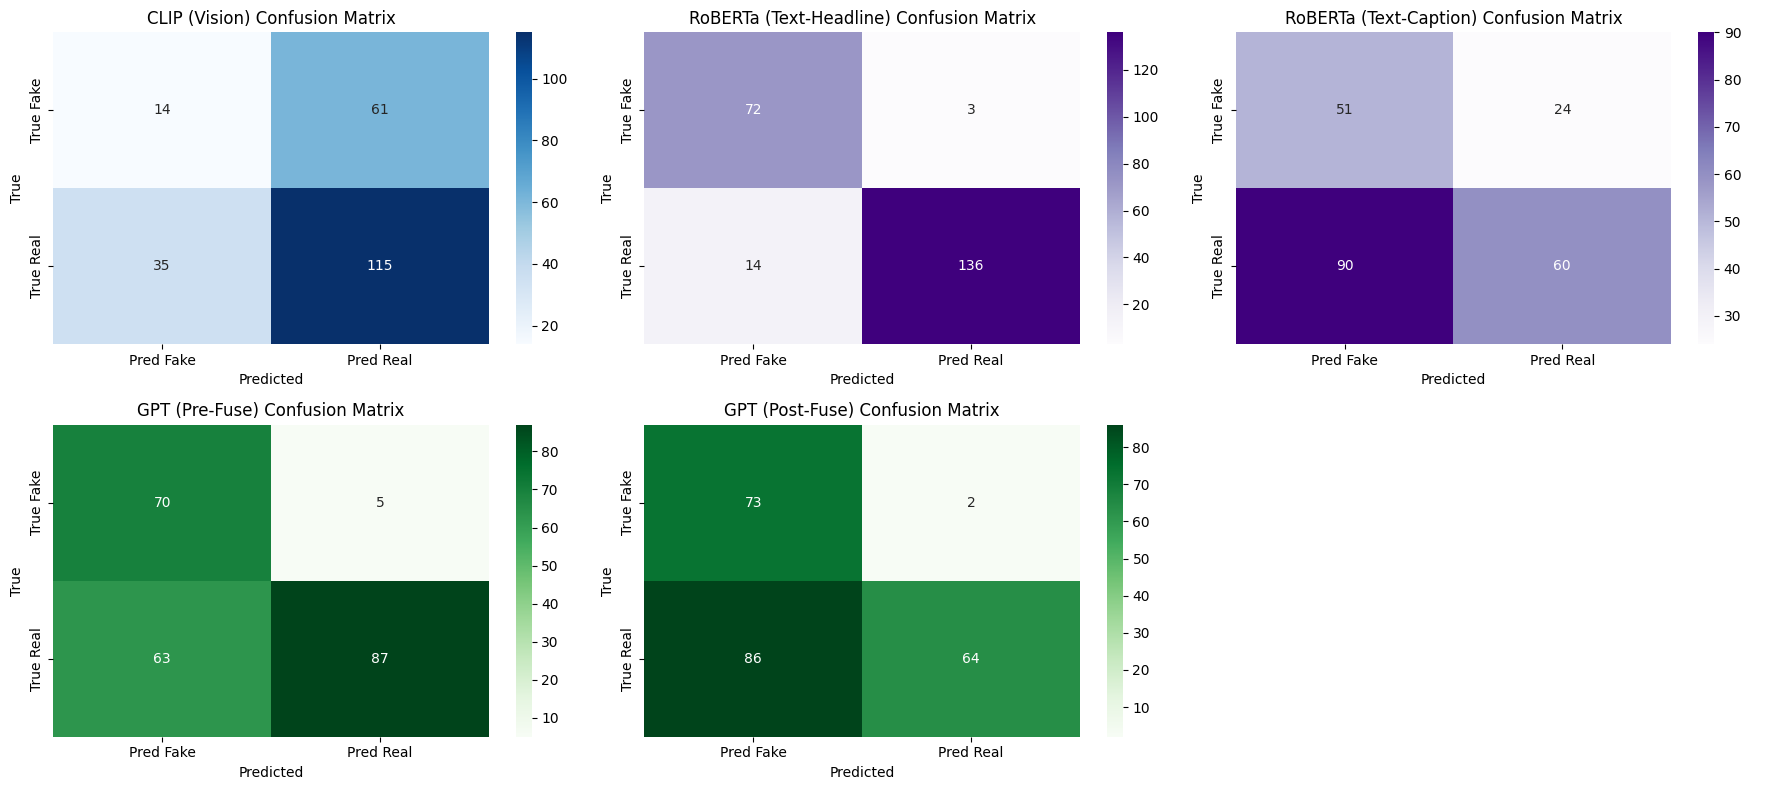

In [106]:
# Heatmaps
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()  # flatten to 1D: axes[0]..axes[5]

sns.heatmap(clip_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[0])
axes[0].set_title("CLIP (Vision) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(robertaT_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[1])
axes[1].set_title("RoBERTa (Text-Headline) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(robertaC_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[2])
axes[2].set_title("RoBERTa (Text-Caption) Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

sns.heatmap(gpt1_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[3])
axes[3].set_title("GPT (Pre-Fuse) Confusion Matrix")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True")

sns.heatmap(gpt2_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[4])
axes[4].set_title("GPT (Post-Fuse) Confusion Matrix")
axes[4].set_xlabel("Predicted")
axes[4].set_ylabel("True")

axes[5].axis("off")

plt.tight_layout()
plt.show()

In [107]:
# Classification reports
print("\n-----------------------------------------------------")
print("CLIP (Vision) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["clip_label_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Text-Headline) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["roberta_text_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Text-Caption) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["roberta_cap_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Pre-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["gpt_pre_int"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Post-Fuse) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    res_df["true_label_int"],
    res_df["gpt_post_int"],
    target_names=["Fake", "Real"]
))


-----------------------------------------------------
RoBERTa (Vision) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.29      0.19      0.23        75
        Real       0.65      0.77      0.71       150

    accuracy                           0.57       225
   macro avg       0.47      0.48      0.47       225
weighted avg       0.53      0.57      0.55       225


-----------------------------------------------------
RoBERTa (Text-Headline) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.84      0.96      0.89        75
        Real       0.98      0.91      0.94       150

    accuracy                           0.92       225
   macro avg       0.91      0.93      0.92       225
weighted avg       0.93      0.92      0.93       225


----------------------------------------

# Observations

**Per-model**

- **CLIP (Vision)** achieves 57.3% accuracy overall, slightly above chance. It has poor recall for fake news (0.19) and a strong bias toward predicting real (61 out of 75 fake examples are misclassified as real). This may suggest that, in this subset, the raw images are largely generic or loosely related to the claim and do not carry a strong, reliable signal about veracity.

- **RoBERTa (Headline)** is by far the strongest component with 92.4% accuracy. It detects fake headlines very reliably (recall 0.96) and keeps false alarms low (precision 0.84), while also performing well on real headlines (0.98 / 0.91 precision/recall). In the initial pipelines (eg, Image-to-Text_Fusion), `roberta-base-openai-detector` was used as text classifier and obtained much lower headline and caption accuracies (≈50% for headlines and ≈43% for captions). However, it is not trained on Fakeddit and is primarily meant to detect GPT-like text, not fake news. Therefore, in the current setup, it is replaced with `yaoyinnan/roberta-fakeddit` (pretrained on Fakeddit dataset). This significant improvement shows that a large fraction of the veracity signal can be extracted from headline text when the classifier is well matched to the dataset, but also highlights how strongly performance depends on model choice, not only on the data.

- **RoBERTa (Caption)**, in contrast, hovers around 49% accuracy, close to random. It shows unbalanced behaviour: reasonably high recall for fake (0.68) but poor recall for real (0.40). Since the captions are BLIP-2 descriptions of the image, not claims about truth, this model is effectively trying to infer veracity from how an image is described, which appears to be a very weak and noisy signal. Note that the captioning model is also changed: earlier experiments used BLIP (`Salesforce/blip-image-captioning-base`), whereas the current setup uses BLIP-2 (`Salesforce/blip2-opt-2.7b`) to generate image descriptions. BLIP-2 produces richer and more accurate captions, which likely contributes to the small improvement in caption-based accuracy (early accuracy with BLIP captions was ≈43%). However, even with BLIP-2 and the Fakeddit-trained RoBERTa, the current caption classifier still remains around chance (49%), suggesting that image-conditioned captions are a relatively weak and noisy signal for fake-news detection in this subset.

- **GPT (Pre-Fuse)**'s initial impression (before calling tools) reaches 69.8% accuracy, clearly worse than headline-RoBERTa but better than CLIP or caption-RoBERTa. GPT is very recall-oriented for fake news (fake recall 0.93), but at the cost of precision (0.53). It tends to over-flag content as fake (63 real items misclassified as fake), behaving like a cautious fact-checker based only on text. Importantly, compared to the initial pipelines, the new agent uses a much more structured system/user prompting scheme and an explicit phase-based workflow, which not only improves the quality of the explanations but also allows us to quantify how tool fusion changes the LLM's decisions (initial vs final) instead of treating it as an opaque black box.

- **GPT (Post-Fuse)**'s accuracy, after consulting the tools, drops to 60.9%. Fake recall becomes extremely high (0.97), but fake precision falls further to 0.46, and real recall drops to 0.43. In other words, the fused blind agent becomes even more conservative, labelling many real posts as fake (86 false positives). The additional signals from CLIP and caption-RoBERTa seem to introduce noise more often than they provide corrective evidence.

**Overall,** these results show that headlines contain the strongest and most reliable signal for fake vs real in this subset of Fakeddit: the RoBERTa headline classifier reaches 92.4% accuracy, while both the CLIP and caption-RoBERTa models perform near chance. The blind GPT agent sits in between: its text-only initial impression reaches 69.8% accuracy, but incorporating multimodal tool outputs actually degrades performance to 60.9%, as the agent becomes overly conservative and over-predicts "Fake". This suggests that, in the blind setup, images and AI captions behave more like weak, noisy cues than strong evidence, and naive fusion of these signals can hurt performance compared to a strong text-only baseline.

**Note. The title "RoBERTa (Vision) Classification Report" is a typo. This plot actually corresponds to the CLIP (Vision) Classification Report (zero-shot CLIP on images only).*